# Convolucion y kernel. INTRODUCCION

---

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

In [5]:
# Conectamos con Drive para conectar
img=cv2.imread('/content/drive/MyDrive/ejemplo_CNN.jpg', cv2.IMREAD_GRAYSCALE)
img = cv2.resize(img, (300, 300)) # Redimensionar para que el bucle de NumPy sea rápido

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


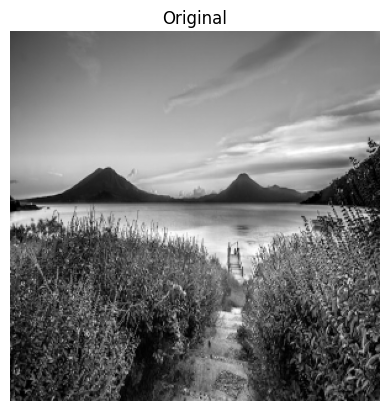

In [7]:
plt.imshow(img, cmap='gray'); plt.title('Original'); plt.axis('off')
plt.show()

In [8]:
f_list=[3,3,2,1,0,0,0,1,3,1,3,1,2,2,3,2,0,0,2,2,2,0,0,0,1]
f=np.array(f_list).reshape(5,5)
f

array([[3, 3, 2, 1, 0],
       [0, 0, 1, 3, 1],
       [3, 1, 2, 2, 3],
       [2, 0, 0, 2, 2],
       [2, 0, 0, 0, 1]])

In [9]:
w_list=[0,1,2,2,2,0,0,1,2]
w=np.array(w_list).reshape(3,3)
w

array([[0, 1, 2],
       [2, 2, 0],
       [0, 1, 2]])

In [10]:
# f: Imagen de entrada y w: Kernel
def convolucion_2d(f,w):
  #Dimensiones de la imagen y el kernel
  f_h,f_w=f.shape
  w_h,w_w=w.shape

  #Tamaño de la imagen de salida sin padding y stride 1
  out_h=f_h-w_h+1
  out_w=f_w-w_w+1
  img_out=np.zeros((out_h,out_w))

  for i in range(out_h):
    for j in range(out_w):
      roi=f[i:i+w_h,j:j+w_w]
      img_out[i,j]=np.sum(roi*w)

  img_out=np.clip(img_out,0,255)
  return img_out

In [11]:
convolucion_2d(f,w)

array([[12., 12., 17.],
       [10., 17., 19.],
       [ 9.,  6., 14.]])

In [12]:
# 1. Filtro de Enfoque (Sharpen)
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

# 2. Filtro de Desenfoque (Blur / Caja)
kernel_blur = np.array([[1, 1, 1],
                        [1, 1, 1],
                        [1, 1, 1]]) / 9.0

# 3. Filtro Sobel Vertical (Detector de bordes verticales)
kernel_sobel_v = np.array([[-1, 0, 1],
                           [-2, 0, 2],
                           [-1, 0, 1]])

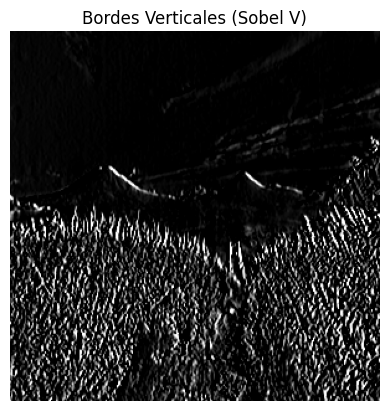

In [13]:
img_edge=convolucion_2d(img,kernel_sobel_v)
plt.imshow(img_edge, cmap='gray'); plt.title('Bordes Verticales (Sobel V)')
plt.axis('off')
plt.show()

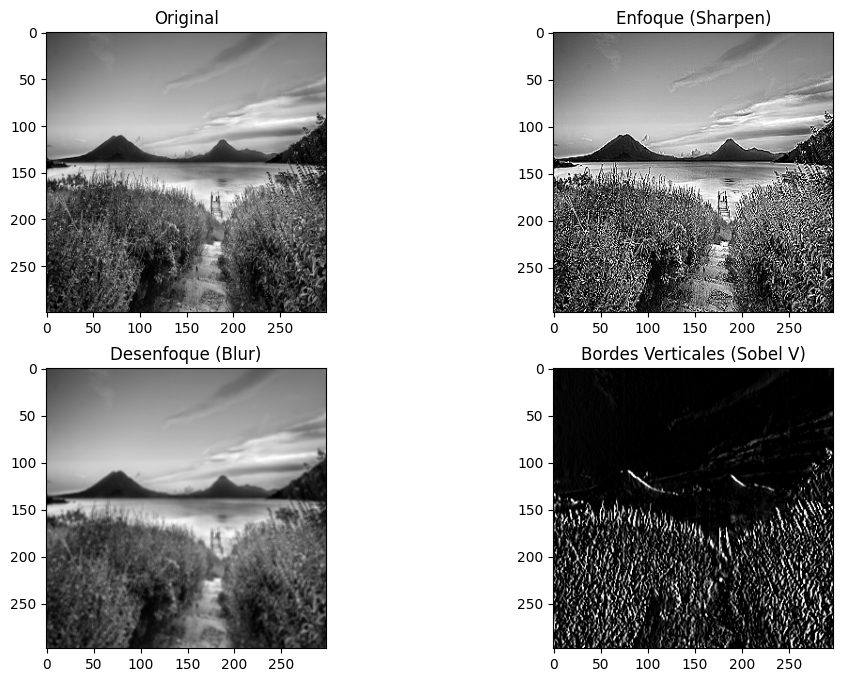

In [14]:
res_sharpen = convolucion_2d(img, kernel_sharpen)
res_blur = convolucion_2d(img, kernel_blur)
res_sobel = convolucion_2d(img, kernel_sobel_v)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1); plt.imshow(img, cmap='gray'); plt.title('Original')
plt.subplot(2, 2, 2); plt.imshow(res_sharpen, cmap='gray'); plt.title('Enfoque (Sharpen)')
plt.subplot(2, 2, 3); plt.imshow(res_blur, cmap='gray'); plt.title('Desenfoque (Blur)')
plt.subplot(2, 2, 4); plt.imshow(res_sobel, cmap='gray'); plt.title('Bordes Verticales (Sobel V)')
plt.show()

# Práctica de Laboratorio: Redes Neuronales Convolucionales Avanzadas

---

### Objetivos de la Sesión:
1. **Dominar Keras Profesional:** Comprender la diferencia práctica entre la API Secuencial y la API Funcional, así como el uso estratégico de Callbacks en entornos de producción.
2. **Evolución contra el Overfitting:** Construir una CNN manual y analizar cómo mitigar el sobreajuste mediante técnicas avanzadas (Aumento de Datos).
3. **Ingeniería Colaborativa (Transfer Learning):** Dividir el grupo en equipos para evaluar, comparar y defender técnicamente diferentes arquitecturas globales preentrenadas (*ResNet, VGG, Xception, MobileNet, DenseNet*).

---

## Bloque de Auditoría: Verificación de Aceleración por Hardware (GPU)

El entrenamiento de redes neuronales profundas requiere billones de operaciones de multiplicación de matrices. Ejecutar esto en un procesador genérico (CPU) puede tomar horas. Las Unidades de Procesamiento Gráfico (**GPU**) permiten paralelizar estas operaciones, reduciendo el tiempo de minutos a segundos.

### 🛠️ ¿Cómo activar la GPU en Google Colab?
1. Ve al menú superior: **Entorno de ejecución** $\rightarrow$ **Cambiar tipo de entorno de ejecución**.
2. En la opción *Acelerador por hardware*, selecciona **T4 GPU**.
3. Da clic en **Guardar** *(Nota: Esto reiniciará el entorno, recuerda volver a correr la celda de carga de datos).*

### 💻 ¿Cómo verificarlo en un Jupyter Notebook Local?
Si corres este código en tu computadora, TensorFlow buscará tarjetas gráficas NVIDIA compatibles con los controladores CUDA instalados en tu sistema operativo.
*(Nota de ingeniería: Recuerda que las versiones modernas de TensorFlow en Windows nativo requieren el uso de WSL2 para poder detectar la GPU).*

In [15]:
import tensorflow as tf
import os

print("--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---")

# 1. Comprobar si TensorFlow tiene acceso a alguna GPU
dispositivos_gpu = tf.config.list_physical_devices('GPU')

if len(dispositivos_gpu) > 0:
    print(f"\n¡ÉXITO! Se detectaron {len(dispositivos_gpu)} GPU(s) disponibles.")
    for i, gpu in enumerate(dispositivos_gpu):
        print(f"  - GPU {i}: {gpu}")

    # Obtener el nombre comercial del dispositivo asignado por Keras
    nombre_gpu = tf.test.gpu_device_name()
    print(f"\nDispositivo activo para Keras: {nombre_gpu}")
else:
    print("\n⚠️ ADVERTENCIA: No se detectó ninguna GPU. TensorFlow está corriendo en CPU.")
    print("Si estás en Colab, ve a Entorno de ejecución -> Cambiar tipo de entorno -> T4 GPU.")

print("\n-----------------------------------------")

# 2. Comando de bajo nivel de NVIDIA (Solo funciona en Linux/Colab o entornos locales con drivers instalados)
# El comando de consola '!nvidia-smi' nos da el reporte de consumo de memoria y el modelo exacto en tiempo real.
try:
    print("Reporte oficial de la tarjeta de video (nvidia-smi):")
    print("====================================================")
    os.system('nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv')
except:
    print("Comando nvidia-smi no disponible en este sistema operativo (común en Windows nativo sin WSL2 o macOS).")

--- DIAGNÓSTICO DE HARDWARE TENSORFLOW ---

¡ÉXITO! Se detectaron 1 GPU(s) disponibles.
  - GPU 0: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

Dispositivo activo para Keras: /device:GPU:0

-----------------------------------------
Reporte oficial de la tarjeta de video (nvidia-smi):


In [16]:
# Introducción Secuencial
import tensorflow as tf
from tensorflow import keras
from keras import layers

modelo_secuencial = keras.Sequential([
    layers.Input(shape=(180, 180, 3)),
    layers.Conv2D(32, 3, activation='relu'),
    layers.Flatten(),
    layers.Dense(1, activation='sigmoid')
], name = "Modelo Secuencial")
modelo_secuencial.summary()

Model: "Modelo Secuencial"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1013888)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │     1,013,889 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,785 (3.87 MB)

 Trainable params: 1,014,785 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# 2 Enfoque funcional (Flexible - Estándar de la Industria)
from tensorflow import keras
from keras import layers

inputs = keras.Input(shape=(180, 180, 3))

x = layers.Conv2D(32, 3, activation='relu')(inputs)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

modelo_funcional = keras.Model(inputs=inputs, outputs=outputs, name="Modelo Funcional")
modelo_funcional.summary()

Model: "Modelo Funcional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1013888)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │     1,013,889 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,014,785 (3.87 MB)

 Trainable params: 1,014,785 (3.87 MB)

 Non-trainable params: 0 (0.00 B)

### El Control del tiempo y Recursos: CallBacks de keras
Entrenar modelos a ciegas durante muchas épocas puede ser ineficiente y desperdiciar recursos computacionales. Los Callbacks permiten controlar, monitorizar y detener el entrenamiento de forma inteligente.

1. EarlyStopping (Parada Temprana)
Detiene el entrenamiento automáticamente cuando una métrica deja de mejorar, evitando épocas innecesarias.

2. ModelCheckpoint (Guardado del Modelo)
Guarda automáticamente el modelo en el mejor momento del entrenamiento.

In [18]:
mis_callback = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    keras.callbacks.ModelCheckpoint(filepath='modelo_mejor.keras', monitor='val_loss', save_best_only=True)
]

In [19]:
import os
import kagglehub
from google.colab import userdata

# Autenticación autimatica y segura
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

print("Autenticación con kaggle")

# 2 Descargar automaticamente el  dataset de perros y gatos
# 2. Descarga automática del dataset optimizado (3,000 imágenes) a través de kagglehub
# Este proceso es sumamente rápido y no satura el internet del aula
path_dataset = kagglehub.dataset_download("birajsth/cats-and-dogs-filtered")
print("Dataset descargado con éxito en la ruta:", path_dataset)

Autenticación con kaggle
Using Colab cache for faster access to the 'cats-and-dogs-filtered' dataset.
Dataset descargado con éxito en la ruta: /kaggle/input/cats-and-dogs-filtered


In [20]:
# 3. Mapeo inteligente de rutas (Verificamos si viene anidado)
if 'cats_and_dogs_filtered' in os.listdir(path_dataset):
    PATH = os.path.join(path_dataset, 'cats_and_dogs_filtered')
else:
    PATH = path_dataset

train_dir = os.path.join(PATH, 'train')
validation_dir = os.path.join(PATH, 'validation')

In [21]:
# 4. Pipeline de datos optimizado usando tf.keras.utils
BATCH_SIZE = 32
IMG_SIZE = (180, 180)

In [22]:
print("\n--- Cargando Set de Entrenamiento ---")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print("\n--- Cargando Set de Validación ---")
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)


--- Cargando Set de Entrenamiento ---
Found 2000 files belonging to 2 classes.

--- Cargando Set de Validación ---
Found 1000 files belonging to 2 classes.


Organizacion del dataset:



```
cats_and_dogs_filtered/
├── train/                  <-- Carpeta de entrenamiento
│   ├── cats/               <-- 1,000 imágenes de gatos (ej. cat.1.jpg, cat.2.jpg...)
│   └── dogs/               <-- 1,000 imágenes de perros (ej. dog.1.jpg, dog.2.jpg...)
└── validation/             <-- Carpeta de validación
    ├── cats/               <-- 500 imágenes de gatos
    └── dogs/               <-- 500 imágenes de perros
```

¿Qué hace internamente image_dataset_from_directory?

Esta función no carga las 3,000 imágenes a la memoria RAM de golpe (eso saturaría las computadoras locales). En su lugar, crea un Generador de datos (tf.data.Dataset).

Internamente, hace cuatro tareas de ingeniería sobre la marcha (on-the-fly):

Decodificación: Convierte los archivos .jpg pesados en matrices numéricas (Tensores).

Redimensionamiento (Resize): Modifica el tamaño original de la foto (venga en la resolución que venga) a exactamente (180, 180) píxeles, porque las CNNs exigen que todas las entradas tengan el mismo tamaño dimensional.

Loteado (Batching): Agrupa las imágenes en paquetes de 32 (BATCH_SIZE = 32). Cada que el modelo pida datos, este generador le entregará un bloque de 32 fotos con sus 32 etiquetas.

Barajado (Shuffle): Mezcla las imágenes para que en un solo lote vayan perros y gatos revueltos, evitando que la red memorice secuencias.

### Exploración de datos (EDA)

In [23]:
# 1. Verificar las clases detectadas automáticamente por la función
nombres_clases = train_dataset.class_names
print("Las clases detectadas y su orden alfabético son:", nombres_clases)
print(f"Por lo tanto: {nombres_clases[0]} = 0, y {nombres_clases[1]} = 1\n")

# 2. Extraer UN SOLO LOTE (Batch) para inspeccionar la anatomía de los tensores
# .take(1) le pide al generador que nos entregue únicamente el primer paquete de 32 imágenes
for lote_imagenes, lote_etiquetas in train_dataset.take(1):
    print("ANATOMÍA DEL LOTE RECIBIDO POR TENSORFLOW:")
    print("------------------------------------------")
    print("Forma del tensor de imágenes (Batch, Alto, Ancho, Canales Color):", lote_imagenes.shape)
    print("Forma del tensor de etiquetas:", lote_etiquetas.shape)
    print("\nPrimeras 10 etiquetas numéricas de este lote (mezcladas):", lote_etiquetas.numpy()[:10])

Las clases detectadas y su orden alfabético son: ['cats', 'dogs']
Por lo tanto: cats = 0, y dogs = 1

ANATOMÍA DEL LOTE RECIBIDO POR TENSORFLOW:
------------------------------------------
Forma del tensor de imágenes (Batch, Alto, Ancho, Canales Color): (32, 180, 180, 3)
Forma del tensor de etiquetas: (32,)

Primeras 10 etiquetas numéricas de este lote (mezcladas): [0 1 1 0 1 1 0 1 1 0]


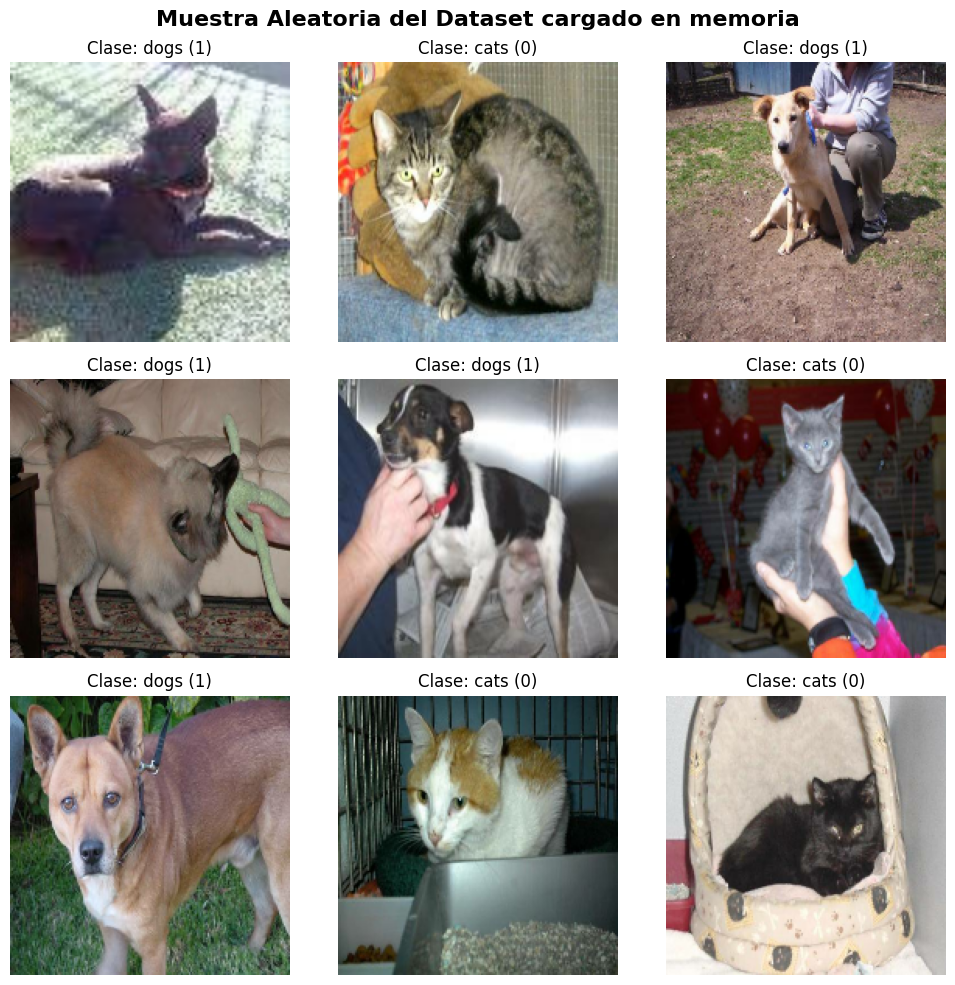

In [24]:
import matplotlib.pyplot as plt

# Graficamos una muestra visual de nuestro dataset
plt.figure(figsize=(10, 10))

# Tomamos 1 lote del set de entrenamiento
for imagenes, etiquetas in train_dataset.take(1):
    for i in range(9): # Mostramos las primeras 9 imágenes del lote
        ax = plt.subplot(3, 3, i + 1)
        # Keras carga las imágenes como flotantes, las casteamos a enteros para Matplotlib
        plt.imshow(imagenes[i].numpy().astype("uint8"))

        # Obtenemos el nombre de la clase usando el índice de la etiqueta
        clase_actual = nombres_clases[etiquetas[i]]

        plt.title(f"Clase: {clase_actual} ({etiquetas[i].numpy()})")
        plt.axis("off")

plt.suptitle("Muestra Aleatoria del Dataset cargado en memoria", fontsize=16, weight='bold')
plt.tight_layout()
plt.show()

### Bloque 3: Diseño de una CNN Manual Base (Sin Regularización)
Vamos a construir nuestra primera Red Neuronal Convolucional clásica desde cero, siguiendo el patrón jerárquico del Capítulo 8: una serie de bloques alternados de Convolución y Max Pooling, terminando en un clasificador denso (MLP).

Puntos clave del diseño en los que deben fijarse:
1. Capa de Normalización (Rescaling): Los valores de los píxeles en las imágenes van de 0 a 255. Las redes neuronales calculan gradientes de forma mucho más estable si los datos de entrada están normalizados en un rango de [0, 1]. Escalamos multiplicando por 1./255.

2. Crecimiento de Filtros: Noten cómo duplicamos el número de filtros en cada bloque (32 -> 64 -> 128). Las primeras capas extraen rasgos geométricos simples (bordes, líneas); las capas más profundas necesitan más filtros para combinar esos bordes y memorizar texturas complejas.

3. Reducción Espacial: Cada capa de MaxPooling2D reduce las dimensiones de alto y ancho a la mitad, forzando a la red a ser invariante a la traslación y reduciendo la carga computacional.

In [25]:
# 1. Definición de la Entrada (Mismo tamaño que configuramos en el dataset)
inputs = keras.Input(shape=(180, 180, 3), name="Input_Visual")

# 2. Preprocesamiento: Escalar píxeles de [0, 255] a [0, 1]
x = layers.Rescaling(1./255, name="Normalizacion_Pixeles")(inputs)

# Bloque Convolucional 1: Extrae características de bajo nivel
x = layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", name="Conv_1")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_1")(x)

# Bloque Convolucional 2: Características intermedias
x = layers.Conv2D(filters=64, kernel_size=(3, 3), activation="relu", name="Conv_2")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_2")(x)

# Bloque Convolucional 3: Características complejas/abstractas
x = layers.Conv2D(filters=128, kernel_size=(3, 3), activation="relu", name="Conv_3")(x)
x = layers.MaxPooling2D(pool_size=(2, 2), name="Max_Pool_3")(x)

# Cabeza Clasificadora (Aplanamos el volumen 3D a un vector 1D)
x = layers.Flatten(name="Aplanado_Volumen")(x)
x = layers.Dense(64, activation="relu", name="Capa_Densa_Intermedia")(x)

# Salida Binaria: Sigmoid nos da la probabilidad de ser Perro (1) frente a Gato (0)
outputs = layers.Dense(1, activation="sigmoid", name="Output_Clasificador")(x)

# Amarrar el modelo final
model_manual = keras.Model(inputs=inputs, outputs=outputs, name="CNN_Manual_Base")

# 3. COMPILACIÓN: Configuramos la pérdida binaria y el optimizador Adam
model_manual.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_manual.summary()

Model: "CNN_Manual_Base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Visual (InputLayer)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Normalizacion_Pixeles           │ (None, 180, 180, 3)    │             0 │
│ (Rescaling)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_1 (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_1 (MaxPooling2D)       │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_2 (Conv2D)                 │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_2 (MaxPooling2D)       │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv_3 (Conv2D)                 │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Max_Pool_3 (MaxPooling2D)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Aplanado_Volumen (Flatten)      │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Capa_Densa_Intermedia (Dense)   │ (None, 64)             │     3,276,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Clasificador (Dense)     │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,370,177 (12.86 MB)

 Trainable params: 3,370,177 (12.86 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Entrenamiuentoi el modelo
history_manual = model_manual.fit(
    train_dataset,
    epochs=15,
    validation_data=validation_dataset,
    callbacks=mis_callback
)



Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.4980 - loss: 0.7350 - val_accuracy: 0.5240 - val_loss: 0.6896
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5630 - loss: 0.6771 - val_accuracy: 0.5020 - val_loss: 0.7182
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 56ms/step - accuracy: 0.6495 - loss: 0.6272 - val_accuracy: 0.6620 - val_loss: 0.6313
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.7170 - loss: 0.5525 - val_accuracy: 0.6870 - val_loss: 0.6439
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.7620 - loss: 0.5045 - val_accuracy: 0.6930 - val_loss: 0.6384
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 52ms/step - accuracy: 0.7810 - loss: 0.4513 - val_accuracy: 0.6860 - val_loss: 0.7405


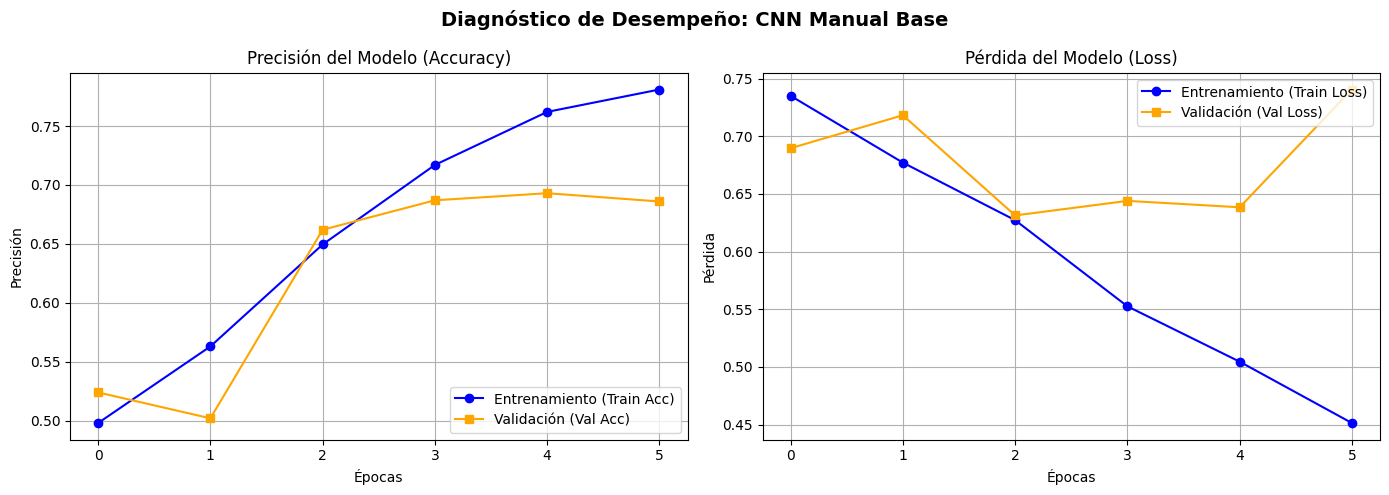

In [27]:
import matplotlib.pyplot as plt

# Extraemos las métricas del historial de entrenamiento
acc = history_manual.history['accuracy']
val_acc = history_manual.history['val_accuracy']
loss = history_manual.history['loss']
val_loss = history_manual.history['val_loss']
epochs_range = range(len(acc))

# Graficar Precisión y Pérdida lado a lado
plt.figure(figsize=(14, 5))

# Gráfica 1: Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento (Train Acc)', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validación (Val Acc)', marker='s', color='orange')
plt.title('Precisión del Modelo (Accuracy)')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend(loc='lower right')
plt.grid(True)

# Gráfica 2: Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento (Train Loss)', marker='o', color='blue')
plt.plot(epochs_range, val_loss, label='Validación (Val Loss)', marker='s', color='orange')
plt.title('Pérdida del Modelo (Loss)')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend(loc='upper right')
plt.grid(True)

plt.suptitle("Diagnóstico de Desempeño: CNN Manual Base", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()